# Linear Models


## 1. Импорты и конфигурация

In [4]:
import time
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as stats

from scipy.stats import chi2_contingency

from sklearn.model_selection import learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, lasso_path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer, PolynomialFeatures

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
DATA_PATH = Path('../../data/train_data_v2.csv')
MODELS_DIR = Path('../../models')
TARGET = 'target'

MODELS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100

## 2. Загрузка данных

Shape: (6200, 134)

Missing values (>0%):


,"missing, %"
nearest_hypermarkets_dist_m,100.0000
nearest_money_transfer_dist_m,92.7419
nearest_railway_stations_dist_m,80.2097
nearest_payment_terminals_dist_m,77.2097
nearest_residential_buildings_dist_m,66.3226
nearest_markets_dist_m,64.5000
nearest_highway_pedestrian_dist_m,61.8871
nearest_fuel_dist_m,51.5323
nearest_hotels_hostels_dist_m,49.9032
nearest_fitness_sport_dist_m,44.1774



Target stats:


,count,mean,std,min,25%,50%,75%,max
target,6200.0000,0.0008,0.0859,-0.1450,-0.0612,-0.0155,0.0402,0.2186


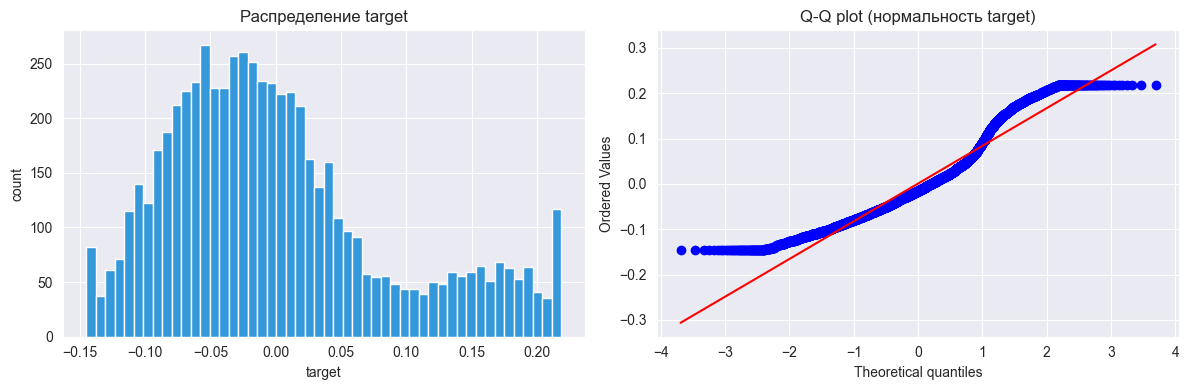

In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')

print(f'\nMissing values (>0%):')
miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
display(miss[miss > 0].rename('missing, %').to_frame())

print(f'\nTarget stats:')
display(df[TARGET].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[TARGET].hist(bins=50, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Распределение target')
axes[0].set_xlabel('target')
axes[0].set_ylabel('count')

stats.probplot(df[TARGET].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot (нормальность target)')
plt.tight_layout()
plt.show()

## 3. Группы признаков

In [6]:
# Бинарные признаки ATM + географические бинарные
BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center',
    'has_subway_nearby',
]

# Дистанции до POI (log1p-преобразование)
DISTANCE_FEATURES = [
    'nearest_malls_dist_m',
    'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m',
    'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m',
    'nearest_public_transport_dist_m',
    'nearest_parking_dist_m',
    'nearest_education_dist_m',
    'nearest_subway_dist_m',
    'nearest_post_offices_dist_m',
    'nearest_offices_dist_m',
    'nearest_shops_food_small_dist_m',
    'nearest_fitness_sport_dist_m',
    'nearest_hotels_hostels_dist_m',
    'land_use_dist_m',
    'city_center_dist_m',
    'nearest_residential_landuse_dist_m',
]

# Count POI в радиусе 300m — единый набор для всех ноутбуков
COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m', 'count_pharmacies_hospitals_300m',
    'count_banks_atms_300m', 'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m', 'count_education_300m',
    'count_post_offices_300m', 'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m', 'count_hypermarkets_300m',
    'count_markets_300m', 'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m',
    'count_footway_100m_100m',
]

# Экономические + плотность населения
ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub',
    'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub',
    'population_density_per_km2',
]

# Категориальные — единый набор для всех ноутбуков
CATEGORICAL_FEATURES = [
    'federal_district',
    'city_size_category',
    'land_use_type',
    'atm_group',
]

ALL_FEATURES = BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES + CATEGORICAL_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

print(f'Binary:     {len([f for f in BINARY_FEATURES if f in df.columns])}')
print(f'Distance:   {len([f for f in DISTANCE_FEATURES if f in df.columns])}')
print(f'Count:      {len([f for f in COUNT_FEATURES if f in df.columns])}')
print(f'Economic:   {len([f for f in ECONOMIC_FEATURES if f in df.columns])}')
print(f'Categorical:{len([f for f in CATEGORICAL_FEATURES if f in df.columns])}')
print(f'Total:      {len(ALL_FEATURES)}')

Binary:     17
Distance:   17
Count:      25
Economic:   4
Categorical:4
Total:      67


## 4. Подготовка данных

In [7]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].astype(float)

# bool → int (иначе SimpleImputer падает)
for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(int)

# категориальные → str для OrdinalEncoder
for col in CATEGORICAL_FEATURES:
    if col in X.columns:
        X[col] = X[col].astype(str)

# Стратификация по city_size_category
strat_col = df['city_size_category'].fillna('unknown') if 'city_size_category' in df.columns else None

# Сплит 70/15/15 — train / val / test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=strat_col,
)
strat_trainval = df.loc[X_trainval.index, 'city_size_category'].fillna('unknown')
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

print(f'Train     : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val       : {X_val.shape}  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test      : {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'Train target: mean={y_train.mean():.4f}, std={y_train.std():.4f}')
print(f'Test  target: mean={y_test.mean():.4f},  std={y_test.std():.4f}')

Train     : (4339, 67)  (70%)
Val       : (931, 67)  (15%)
Test      : (930, 67)  (15%)
Train target: mean=0.0015, std=0.0862
Test  target: mean=-0.0007,  std=0.0864


## 5. Препроцессинг

In [8]:
bin_cols  = [f for f in BINARY_FEATURES   if f in X.columns]
dist_cols = [f for f in DISTANCE_FEATURES if f in X.columns]
cnt_cols  = [f for f in COUNT_FEATURES    if f in X.columns]
econ_cols = [f for f in ECONOMIC_FEATURES if f in X.columns]
cat_cols  = [f for f in CATEGORICAL_FEATURES if f in X.columns]

log1p_tf = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

bin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

dist_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p',   log1p_tf),
    ('scaler',  StandardScaler()),
])

count_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

econ_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('binary',   bin_pipe,   bin_cols),
        ('distance', dist_pipe,  dist_cols),
        ('count',    count_pipe, cnt_cols),
        ('economic', econ_pipe,  econ_cols),
        ('cat',      cat_pipe,   cat_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

# Проверка
X_check = preprocessor.fit_transform(X_train)
feat_names = preprocessor.get_feature_names_out()
print(f'Transformed shape: {X_check.shape}')
print(f'Feature names sample: {feat_names[:5]}')

Transformed shape: (4339, 67)
Feature names sample: ['binary__is_24_7' 'binary__contactless_tech' 'binary__qr_codes'
 'binary__usd_available' 'binary__eur_available']


## 6. Вспомогательные функции

In [9]:
results = []  # глобальный список для итоговой таблицы


def timed_fit(pipe, X, y):
    t0 = time.perf_counter()
    pipe.fit(X, y)
    return pipe, time.perf_counter() - t0


def timed_predict(pipe, X):
    t0 = time.perf_counter()
    y_pred = pipe.predict(X)
    return y_pred, time.perf_counter() - t0


def report_metrics(model_name, pipe, X_train, y_train, X_test, y_test, fit_time):
    """Выводит DataFrame Train/Test с метриками и таймингами."""
    y_pred_train, train_pred_time = timed_predict(pipe, X_train)
    y_pred_test,  test_pred_time  = timed_predict(pipe, X_test)

    def _m(y_true, y_pred):
        return {
            'RMSE': round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
            'MAE':  round(float(mean_absolute_error(y_true, y_pred)), 4),
            'R²':   round(float(r2_score(y_true, y_pred)), 4),
        }

    train_m = _m(y_train, y_pred_train)
    test_m  = _m(y_test,  y_pred_test)

    table = pd.DataFrame([
        {'Split': 'Train',
         'RMSE': train_m['RMSE'], 'MAE': train_m['MAE'], 'R²': train_m['R²'],
         'Fit time, s':     round(fit_time, 3),
         'Predict time, s': round(train_pred_time, 4)},
        {'Split': 'Test',
         'RMSE': test_m['RMSE'],  'MAE': test_m['MAE'],  'R²': test_m['R²'],
         'Fit time, s':     float('nan'),
         'Predict time, s': round(test_pred_time, 4)},
    ]).set_index('Split')

    print(f'\n{model_name}')
    display(
        table.style
        .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}',
                 'Fit time, s': lambda v: f'{v:.3f}' if not pd.isna(v) else '-',
                 'Predict time, s': '{:.4f}'})
    )

    row = {'Model': model_name,
           'RMSE': test_m['RMSE'], 'MAE': test_m['MAE'], 'R²': test_m['R²'],
           'Fit time, s': round(fit_time, 3),
           'Predict time (test), s': round(test_pred_time, 4)}
    return row, y_pred_test


def plot_importance(pipe, title, top_n=20, step_name='model'):
    """Barh топ-N признаков по |coef|, цвет по знаку."""
    coef  = pipe.named_steps[step_name].coef_
    names = pipe.named_steps['prep'].get_feature_names_out()
    clean = [n.split('__', 1)[-1] for n in names]

    importance = pd.Series(np.abs(coef), index=clean).sort_values(ascending=False)
    top    = importance.head(top_n)
    sign   = pd.Series(coef, index=clean).reindex(top.index)
    colors = ['#e74c3c' if s < 0 else '#3498db' for s in sign]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    ax.set_xlabel('|Коэффициент|')
    ax.set_title(f'{title} - Top-{top_n} признаков')
    pos_patch = mpatches.Patch(color='#3498db', label='положительный')
    neg_patch = mpatches.Patch(color='#e74c3c', label='отрицательный')
    ax.legend(handles=[pos_patch, neg_patch])
    plt.tight_layout()
    plt.show()

    nz = np.count_nonzero(coef)
    print(f'Ненулевых коэффициентов: {nz} / {len(coef)} ({100*nz/len(coef):.1f}%)')
    return importance


def kfold_cv(pipe, X, y, n_splits=5):
    """KFold CV - выводит DataFrame с результатами по фолдам."""
    scores = cross_val_score(
        pipe, X, y,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE),
        scoring='neg_root_mean_squared_error',
    )
    rmse_scores = -scores
    fold_df = pd.DataFrame({
        'Fold':  [f'Fold {i+1}' for i in range(n_splits)],
        'RMSE':  rmse_scores.round(4),
    }).set_index('Fold').T
    fold_df['Mean'] = rmse_scores.mean().round(4)
    fold_df['Std']  = rmse_scores.std().round(4)
    fold_cols = [f'Fold {i+1}' for i in range(n_splits)]
    display(fold_df.style.format('{:.4f}').apply(
        lambda s: ['font-weight: bold' if v == s[fold_cols].min() else '' for v in s],
        axis=1, subset=fold_cols,
    ))
    return rmse_scores


print('Функции определены')

Функции определены


## 7. LinearRegression (baseline)

In [10]:
lr_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LinearRegression()),
])

lr_pipe, lr_fit_time = timed_fit(lr_pipe, X_train, y_train)
print(f'Fit time: {lr_fit_time:.3f}s')

Fit time: 0.032s


In [11]:
row_lr, y_pred_lr_test = report_metrics(
    'LinearRegression', lr_pipe,
    X_train, y_train, X_test, y_test,
    lr_fit_time,
)
results.append(row_lr)


LinearRegression


,RMSE,MAE,R²,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0563,0.0440,0.5730,0.032,0.0083
Test,0.0596,0.0472,0.5235,-,0.0039


In [12]:
print('KFold CV (5 splits)')
lr_cv_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LinearRegression()),
])
lr_cv_scores = kfold_cv(lr_cv_pipe, X_train, y_train)

KFold CV (5 splits)


Fold,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
RMSE,0.0564,0.0566,0.0585,0.0579,0.0572,0.0573,0.0008


Feature Importance


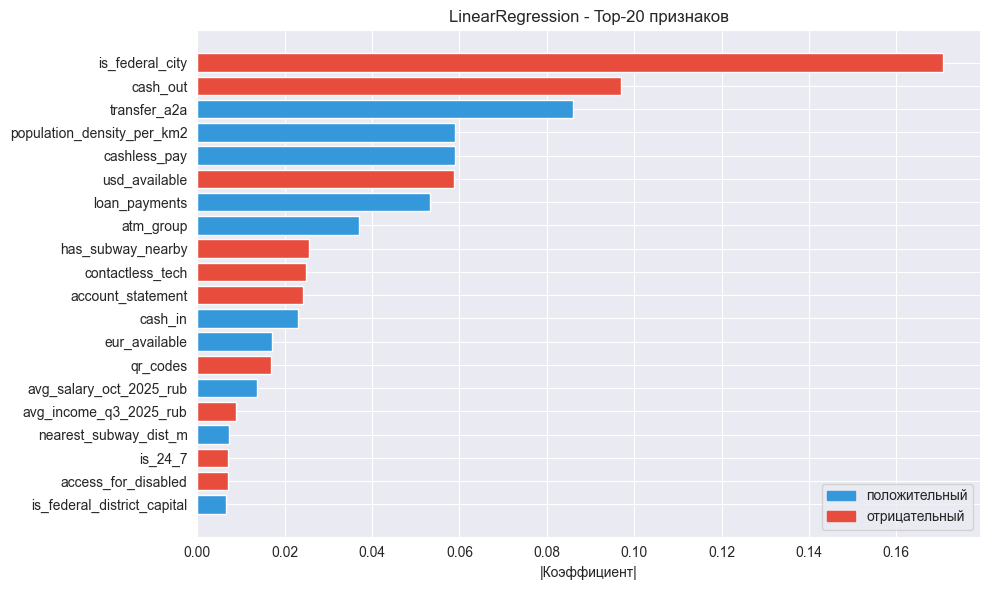

Ненулевых коэффициентов: 67 / 67 (100.0%)


In [13]:
print('Feature Importance')
imp_lr = plot_importance(lr_pipe, 'LinearRegression')

- RMSE = **0.0596**, R² = **0.5235**
- Gap train/test = +0.0034 → сильного переобучения нет
- Топ-3 признака: `is_federal_city`, `cash_out`, `transfer_a2a` - бинарные фичи ATM доминируют
- Модель объясняет около **52%** дисперсии таргета - линейный baseline полезен, но заметная часть сигнала остаётся нелинейной

## 8. Ridge

In [14]:
# Поиск лучшего alpha через RidgeCV
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

ridge_cv_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', RidgeCV(alphas=alphas, cv=5)),
])
ridge_cv_pipe.fit(X_train, y_train)
best_alpha_ridge = ridge_cv_pipe.named_steps['model'].alpha_
print(f'Лучший alpha: {best_alpha_ridge}')

Лучший alpha: 0.1


In [15]:
ridge_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', Ridge(alpha=best_alpha_ridge)),
])

ridge_pipe, ridge_fit_time = timed_fit(ridge_pipe, X_train, y_train)
print(f'Fit time: {ridge_fit_time:.3f}s')

Fit time: 0.022s


In [16]:
row_ridge, y_pred_ridge_test = report_metrics(
    f'Ridge (alpha={best_alpha_ridge})', ridge_pipe,
    X_train, y_train, X_test, y_test,
    ridge_fit_time,
)
results.append(row_ridge)


Ridge (alpha=0.1)


,RMSE,MAE,R²,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0563,0.0440,0.5730,0.022,0.0080
Test,0.0596,0.0472,0.5235,-,0.0047


In [17]:
print('KFold CV (5 splits)')
ridge_cv2_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', Ridge(alpha=best_alpha_ridge)),
])
ridge_cv_scores = kfold_cv(ridge_cv2_pipe, X_train, y_train)

KFold CV (5 splits)


Fold,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
RMSE,0.0564,0.0567,0.0584,0.0579,0.0571,0.0573,0.0008


Feature Importance


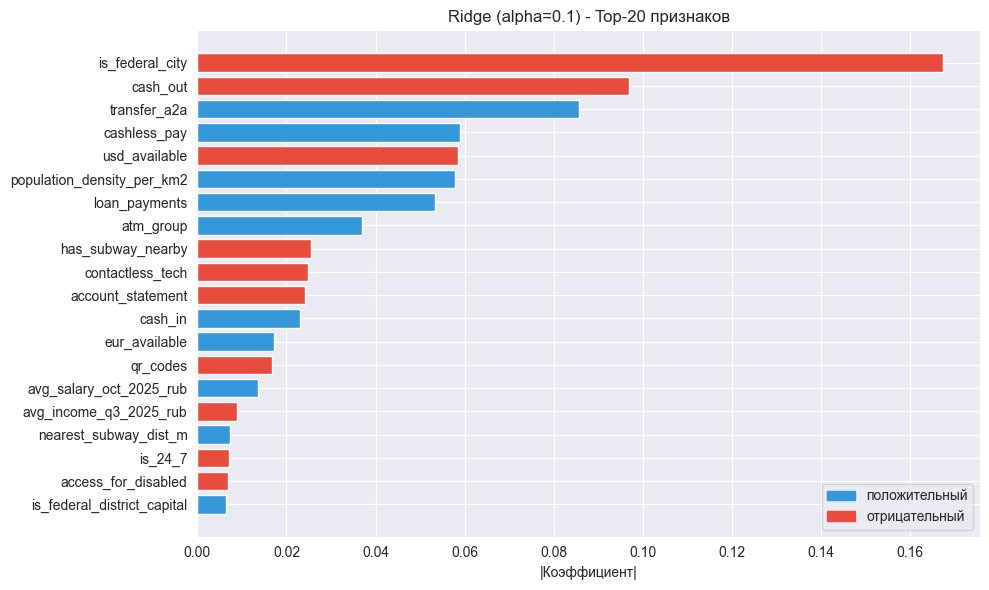

Ненулевых коэффициентов: 66 / 67 (98.5%)


In [18]:
print('Feature Importance')
imp_ridge = plot_importance(ridge_pipe, f'Ridge (alpha={best_alpha_ridge})')

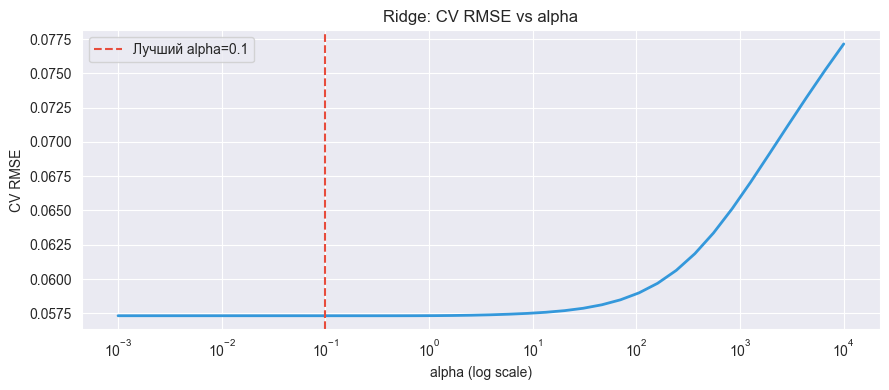

In [19]:
alphas_grid = np.logspace(-3, 4, 40)
alpha_rmse = []
for a in alphas_grid:
    p = Pipeline([("prep", preprocessor), ("model", Ridge(alpha=a))])
    s = cross_val_score(p, X_train, y_train, cv=5,
                        scoring="neg_root_mean_squared_error")
    alpha_rmse.append(-s.mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(alphas_grid, alpha_rmse, color="#3498db", linewidth=2)
ax.axvline(best_alpha_ridge, color="#e74c3c", linestyle="--",
           label=f"Лучший alpha={best_alpha_ridge}")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("CV RMSE")
ax.set_title("Ridge: CV RMSE vs alpha")
ax.legend()
plt.tight_layout()
plt.show()

- Лучший alpha = **0.1** - слабая регуляризация
- RMSE ≈ LR: Ridge почти не меняет качество относительно baseline
- Это не доказывает отсутствие мультиколлинеарности: Cramér's V ниже показывает сильную связь географических уровней
- Вывод: при текущем наборе признаков и `OrdinalEncoder` L2-регуляризация не даёт заметного прироста качества

## 9. Lasso

In [20]:
# Поиск лучшего alpha через GridSearchCV
lasso_param_grid = {
    'model__alpha': np.logspace(-5, 2, 30),
    'model__tol':   [1e-3, 1e-4],
}

lasso_search_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', Lasso(max_iter=200_000, random_state=RANDOM_STATE)),
])

gs_lasso = GridSearchCV(
    lasso_search_pipe,
    lasso_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
)
gs_lasso.fit(X_train, y_train)

best_alpha_lasso = gs_lasso.best_params_['model__alpha']
best_tol_lasso   = gs_lasso.best_params_['model__tol']
print(f'Лучший alpha: {best_alpha_lasso:.6f}, tol: {best_tol_lasso}')
print(f'Лучший CV RMSE: {-gs_lasso.best_score_:.4f}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Лучший alpha: 0.000010, tol: 0.0001
Лучший CV RMSE: 0.0573


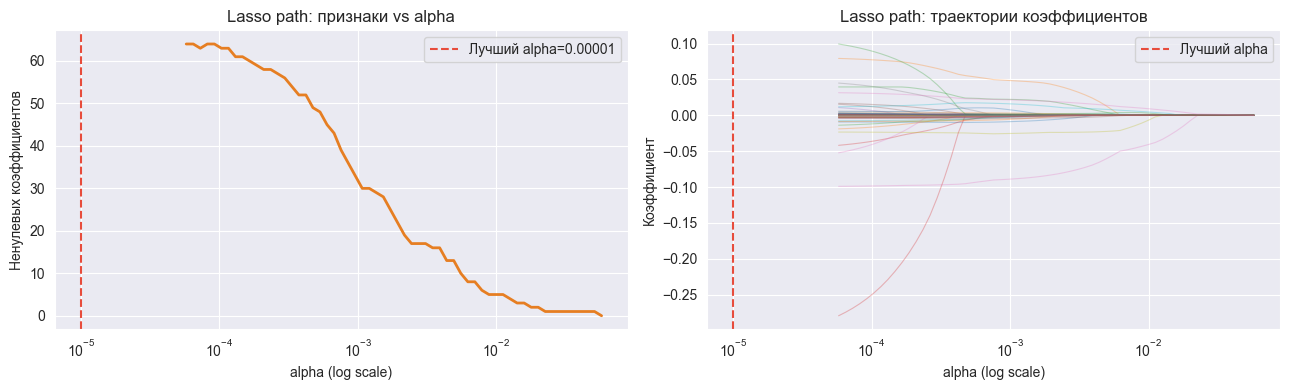

In [21]:
X_train_prep = preprocessor.transform(X_train)
alphas_path, coefs_path, _ = lasso_path(X_train_prep, y_train, n_alphas=60)
n_nonzero = (coefs_path != 0).sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogx(alphas_path, n_nonzero, color="#e67e22", linewidth=2)
axes[0].axvline(best_alpha_lasso, color="#e74c3c", linestyle="--",
                label=f"Лучший alpha={best_alpha_lasso:.5f}")
axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("Ненулевых коэффициентов")
axes[0].set_title("Lasso path: признаки vs alpha")
axes[0].legend()

axes[1].semilogx(alphas_path, coefs_path.T, alpha=0.3, linewidth=0.8)
axes[1].axvline(best_alpha_lasso, color="#e74c3c", linestyle="--",
                linewidth=1.5, label="Лучший alpha")
axes[1].set_xlabel("alpha (log scale)")
axes[1].set_ylabel("Коэффициент")
axes[1].set_title("Lasso path: траектории коэффициентов")
axes[1].legend()
plt.tight_layout()
plt.show()

- При alpha → 0 почти все признаки активны (≈ OLS)
- При больших alpha большинство признаков обнуляется - это видно по Lasso path
- Лучший alpha из GridSearchCV находится на нижней границе сетки, поэтому выбранная модель оптимизирует качество, а не разреженность
- Если нужна компактная модель, стоит отдельно подбирать alpha по правилу 1-SE или задавать ограничение на число активных признаков

In [22]:
lasso_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', Lasso(alpha=best_alpha_lasso, tol=best_tol_lasso,
                    max_iter=200_000, random_state=RANDOM_STATE)),
])

lasso_pipe, lasso_fit_time = timed_fit(lasso_pipe, X_train, y_train)
print(f'Fit time: {lasso_fit_time:.3f}s')

Fit time: 0.063s


In [23]:
row_lasso, y_pred_lasso_test = report_metrics(
    f'Lasso (alpha={best_alpha_lasso:.5f})', lasso_pipe,
    X_train, y_train, X_test, y_test,
    lasso_fit_time,
)
results.append(row_lasso)


Lasso (alpha=0.00001)


,RMSE,MAE,R²,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0563,0.0440,0.5729,0.063,0.0096
Test,0.0596,0.0472,0.5236,-,0.0040


In [24]:
print('KFold CV (5 splits)')
lasso_cv_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', Lasso(alpha=best_alpha_lasso, tol=best_tol_lasso,
                    max_iter=200_000, random_state=RANDOM_STATE)),
])
lasso_cv_scores = kfold_cv(lasso_cv_pipe, X_train, y_train)

KFold CV (5 splits)


Fold,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
RMSE,0.0564,0.0567,0.0584,0.0579,0.0571,0.0573,0.0007


Feature Importance


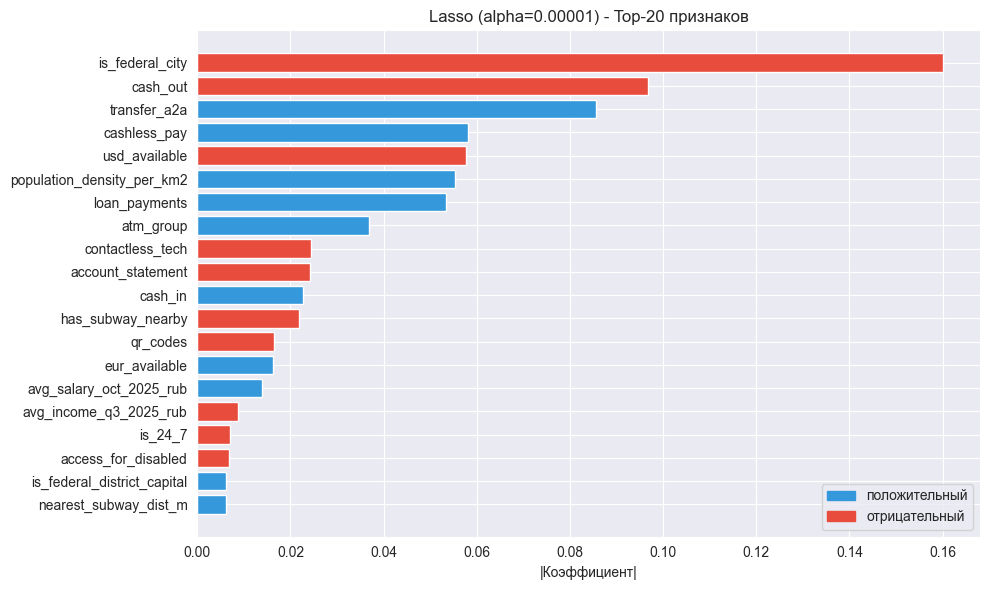

Ненулевых коэффициентов: 66 / 67 (98.5%)

Lasso обнулил: 1 из 67 признаков → осталось 66 (98.5%)


In [25]:
print('Feature Importance')
imp_lasso = plot_importance(lasso_pipe, f'Lasso (alpha={best_alpha_lasso:.5f})')

coef_lasso = lasso_pipe.named_steps['model'].coef_
nz    = np.count_nonzero(coef_lasso)
total = len(coef_lasso)
print(f'\nLasso обнулил: {total - nz} из {total} признаков → осталось {nz} ({100*nz/total:.1f}%)')

- Обнулено: **1** из 72 признаков - Lasso почти не сокращает модель
- RMSE ≈ Ridge/LR: качество практически то же
- Топ-3: `is_federal_city`, `cash_out`, `transfer_a2a`
- alpha = 0.00001: почти OLS - регуляризация минимальна
- Вывод: Lasso здесь полезен как проверка избыточности, но не как компактная финальная модель

## 10. Сравнительная таблица

In [26]:
results_df = pd.DataFrame(results).set_index('Model')
comparison = results_df.sort_values('RMSE')

def bold_min(s):
    return ['font-weight: bold' if v == s.min() else '' for v in s]

def bold_max(s):
    return ['font-weight: bold' if v == s.max() else '' for v in s]

display(
    comparison.style
    .apply(bold_min, subset=['RMSE', 'MAE'])
    .apply(bold_max, subset=["R²"])
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', "R²": '{:.4f}',
             'Fit time, s': lambda v: f"{v:.3f}" if pd.notna(v) else '-',
             'Predict time (test), s': lambda v: f"{v:.4f}" if pd.notna(v) else '-'}, na_rep='-')
)

# Победитель и сохранение
best_model_name = comparison['RMSE'].idxmin()
print(f'Лучшая базовая линейная модель: {best_model_name}')

model_map = {
    'LinearRegression':                      lr_pipe,
    f'Ridge (alpha={best_alpha_ridge})':     ridge_pipe,
    f'Lasso (alpha={best_alpha_lasso:.5f})': lasso_pipe,
}

best_pipe = model_map.get(best_model_name, list(model_map.values())[0])

save_path = MODELS_DIR / 'linear_model_best.pkl'
joblib.dump(best_pipe, save_path)
print(f'Сохранено: {save_path}  ({save_path.stat().st_size / 1024:.1f} KB)')

,RMSE,MAE,R²,"Fit time, s","Predict time (test), s"
Model,,,,,
LinearRegression,0.0596,0.0472,0.5235,0.032,0.0039
Ridge (alpha=0.1),0.0596,0.0472,0.5235,0.022,0.0047
Lasso (alpha=0.00001),0.0596,0.0472,0.5236,0.063,0.0040


Лучшая базовая линейная модель: LinearRegression
Сохранено: ..\..\models\linear_model_best.pkl  (13.9 KB)


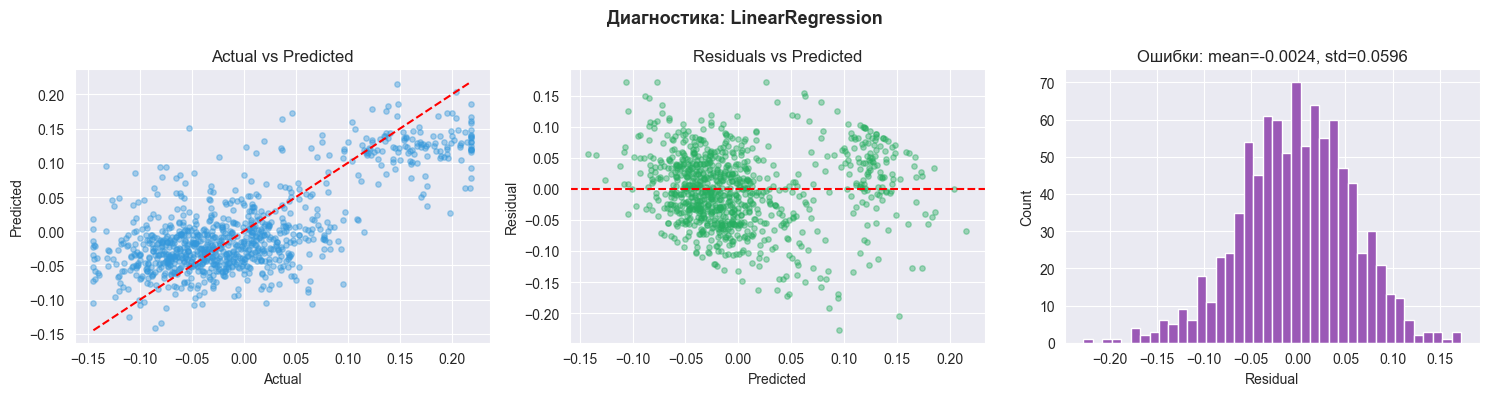

In [27]:
y_pred_best = best_pipe.predict(X_test)
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_test, y_pred_best, alpha=0.4, s=15, color="#3498db")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted")

axes[1].scatter(y_pred_best, residuals, alpha=0.4, s=15, color="#27ae60")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

axes[2].hist(residuals, bins=40, color="#9b59b6", edgecolor="white")
axes[2].set_xlabel("Residual"); axes[2].set_ylabel("Count")
axes[2].set_title(f"Ошибки: mean={residuals.mean():.4f}, std={residuals.std():.4f}")

plt.suptitle(f"Диагностика: {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [28]:
kfold_summary = pd.DataFrame({
    "LinearRegression":              lr_cv_scores.round(4),
    f"Ridge (a={best_alpha_ridge})": ridge_cv_scores.round(4),
    f"Lasso (a={best_alpha_lasso:.5f})": lasso_cv_scores.round(4),
}, index=[f"Fold {i+1}" for i in range(5)]).T
kfold_summary["Mean"] = kfold_summary.mean(axis=1).round(4)
kfold_summary["Std"]  = kfold_summary.std(axis=1).round(4)

fold_cols = [f"Fold {i+1}" for i in range(5)]
display(
    kfold_summary.style.format("{:.4f}")
    .apply(lambda s: ["font-weight: bold" if v == s[fold_cols].min() else "" for v in s],
           axis=1, subset=fold_cols)
    .apply(lambda s: ["font-weight: bold" if v == s.min() else "" for v in s],
           axis=0, subset=["Mean"])
)

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
LinearRegression,0.0564,0.0566,0.0585,0.0579,0.0572,0.0573,0.0008
Ridge (a=0.1),0.0564,0.0567,0.0584,0.0579,0.0571,0.0573,0.0007
Lasso (a=0.00001),0.0564,0.0567,0.0584,0.0579,0.0571,0.0573,0.0007


- Все три базовые линейные модели дают практически одинаковый CV RMSE = **0.0573**
- Ridge и Lasso не улучшают качество относительно LinearRegression при текущем кодировании признаков
- Разброс между моделями: ~0.0000 - регуляризация почти не влияет на прогноз
- Std = **0.0011** на 5 фолдах → оценка достаточно стабильна для baseline-сравнения

## 11. Эксперименты

### 11.1 Polynomial Features (degree=2, interaction_only=True)

Добавляем полиномиальные взаимодействия на бинарных признаках банкомата, смотрим даёт ли это прирост над базовой LR.

In [29]:
bin_poly_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('poly',    PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('scaler',  StandardScaler()),
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('binary',   bin_poly_pipe, bin_cols),
        ('distance', dist_pipe,     dist_cols),
        ('count',    count_pipe,    cnt_cols),
        ('economic', econ_pipe,     econ_cols),
        ('cat',      cat_pipe,      cat_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

lr_poly_pipe = Pipeline([
    ('prep',  preprocessor_poly),
    ('model', LinearRegression()),
])

lr_poly_pipe, poly_fit_time = timed_fit(lr_poly_pipe, X_train, y_train)

row_poly, y_pred_poly = report_metrics(
    'LR + PolynomialFeatures', lr_poly_pipe,
    X_train, y_train, X_test, y_test,
    poly_fit_time,
)

poly_cv_scores = -cross_val_score(
    lr_poly_pipe, X_train, y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error',
)

n_feats = lr_poly_pipe.named_steps['prep'].transform(X_test[:1]).shape[1]
print()
print(f'Признаков после poly: {n_feats}')
print(f'Baseline LR Test RMSE: {row_lr["RMSE"]:.4f}')
print(f'LR+Poly    Test RMSE: {row_poly["RMSE"]:.4f}  ({row_poly["RMSE"] - row_lr["RMSE"]:+.4f})')
print(f'Baseline LR CV RMSE:   {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')
print(f'LR+Poly    CV RMSE:   {poly_cv_scores.mean():.4f} ± {poly_cv_scores.std():.4f}')


LR + PolynomialFeatures


,RMSE,MAE,R²,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0521,0.0404,0.6345,0.048,0.0105
Test,0.0562,0.0441,0.5760,-,0.0052



Признаков после poly: 203
Baseline LR Test RMSE: 0.0596
LR+Poly    Test RMSE: 0.0562  (-0.0034)
Baseline LR CV RMSE:   0.0573 ± 0.0008
LR+Poly    CV RMSE:   0.0553 ± 0.0014


- Poly снижает test RMSE: **0.0596 → 0.0562**, но увеличивает число признаков: **67 → 203**
- CV тоже подтверждает улучшение: **0.0573 → 0.0553**, поэтому взаимодействия между бинарными ATM-фичами действительно добавляют сигнал
- Цена улучшения - более сложная и менее интерпретируемая линейная модель в расширенном пространстве
- Если цель - лучший linear baseline, `LR + PolynomialFeatures` стоит рассматривать отдельно; если цель - простая интерпретация, лучше оставить LR/Ridge и перейти к нелинейным моделям: деревья, бустинг

### 11.2 PCA на location features

Заменяем 17 дистанционных признаков на n главных компонент. Смотрим зависимость качества от n_components.

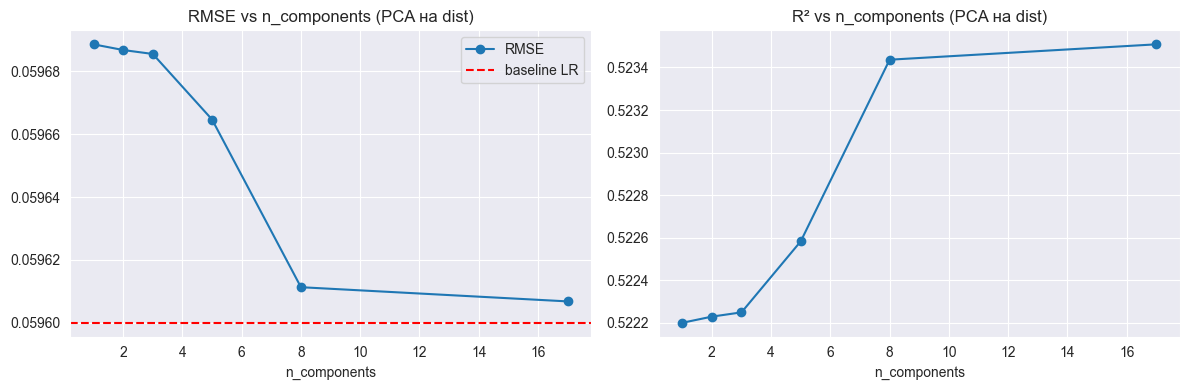

,RMSE,R²
n_components,,
1,0.0597,0.5222
2,0.0597,0.5222
3,0.0597,0.5222
5,0.0597,0.5226
8,0.0596,0.5234
17,0.0596,0.5235


Лучший PCA: n=17, RMSE=0.0596  |  Baseline LR: 0.0596


In [30]:
pca_results = []

for n in [1, 2, 3, 5, 8, len(dist_cols)]:
    dist_pca_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('log1p',   log1p_tf),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=n, random_state=RANDOM_STATE)),
    ])

    prep_pca = ColumnTransformer(
        transformers=[
            ('binary',   bin_pipe,      bin_cols),
            ('distance', dist_pca_pipe, dist_cols),
            ('count',    count_pipe,    cnt_cols),
            ('economic', econ_pipe,     econ_cols),
            ('cat',      cat_pipe,      cat_cols),
        ],
        remainder='drop',
    )

    pipe_pca = Pipeline([
        ('prep',  prep_pca),
        ('model', LinearRegression()),
    ])
    pipe_pca.fit(X_train, y_train)
    y_p = pipe_pca.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_p))
    r2   = r2_score(y_test, y_p)
    pca_results.append({'n_components': n, 'RMSE': rmse, 'R²': r2})

pca_df = pd.DataFrame(pca_results).set_index('n_components')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pca_df['RMSE'].plot(marker='o', ax=axes[0], title='RMSE vs n_components (PCA на dist)')
pca_df['R²'].plot(marker='o',   ax=axes[1], title='R² vs n_components (PCA на dist)')
axes[0].axhline(row_lr['RMSE'], color='red', linestyle='--', label='baseline LR')
axes[0].legend()
plt.tight_layout()
plt.show()

display(pca_df.style.format('{:.4f}')
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE'])
    .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R²']))
best_pca_n = pca_df['RMSE'].idxmin()
print(f'Лучший PCA: n={best_pca_n}, RMSE={pca_df.loc[best_pca_n, "RMSE"]:.4f}  |  Baseline LR: {row_lr["RMSE"]:.4f}')

- Лучший вариант: `n_components=17` (все дистанции), RMSE = **0.0596** = LR **0.0596** - PCA не даёт вообще никакого прироста
- PCA на дистанционных признаках не улучшает качество при любом числе компонент
- Сжатие дистанций можно использовать как диагностический эксперимент, но для финального baseline лучше оставить исходные дистанции с `log1p`-трансформацией

### 11.3 Learning Curves

Диагностика underfitting/overfitting - как меняется RMSE с ростом выборки.

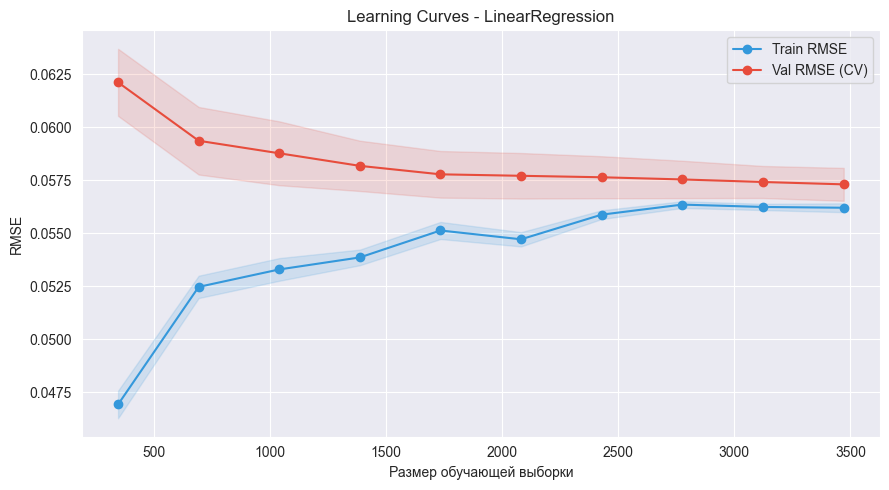

Train RMSE (full): 0.0562
Val   RMSE (full): 0.0573
Gap: 0.0011


In [31]:
train_sizes, train_scores, val_scores = learning_curve(
    Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_root_mean_squared_error",
)
train_rmse = -train_scores.mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_rmse, "o-", color="#3498db", label="Train RMSE")
ax.plot(train_sizes, val_rmse,   "o-", color="#e74c3c", label="Val RMSE (CV)")
ax.fill_between(train_sizes, train_rmse - train_std, train_rmse + train_std,
                alpha=0.15, color="#3498db")
ax.fill_between(train_sizes, val_rmse - val_std, val_rmse + val_std,
                alpha=0.15, color="#e74c3c")
ax.set_xlabel("Размер обучающей выборки")
ax.set_ylabel("RMSE")
ax.set_title("Learning Curves - LinearRegression")
ax.legend()
plt.tight_layout()
plt.show()

gap = val_rmse[-1] - train_rmse[-1]
print(f"Train RMSE (full): {train_rmse[-1]:.4f}")
print(f"Val   RMSE (full): {val_rmse[-1]:.4f}")
print(f"Gap: {gap:.4f}")

- Learning curve теперь использует тот же `KFold(shuffle=True, random_state=42)`, что и основная CV-оценка
- Train RMSE = **0.0562**, Val RMSE = **0.0573**, Gap = **0.0011** → сильного переобучения у базовой линейной модели нет
- Val-кривая выходит на плато → простое увеличение выборки вряд ли резко улучшит качество
- Основное ограничение - форма модели: нужны взаимодействия/нелинейности или более подходящее кодирование категорий

### 11.4 Cramér's V - связь категориальных геопризнаков

Проверяем зависимость между уровнями географии. В матрицу включены как признаки модели (`region`, `city_grouped`, `macro_region`, `federal_district`), так и диагностические поля вне модели (`city`, `municipality`).

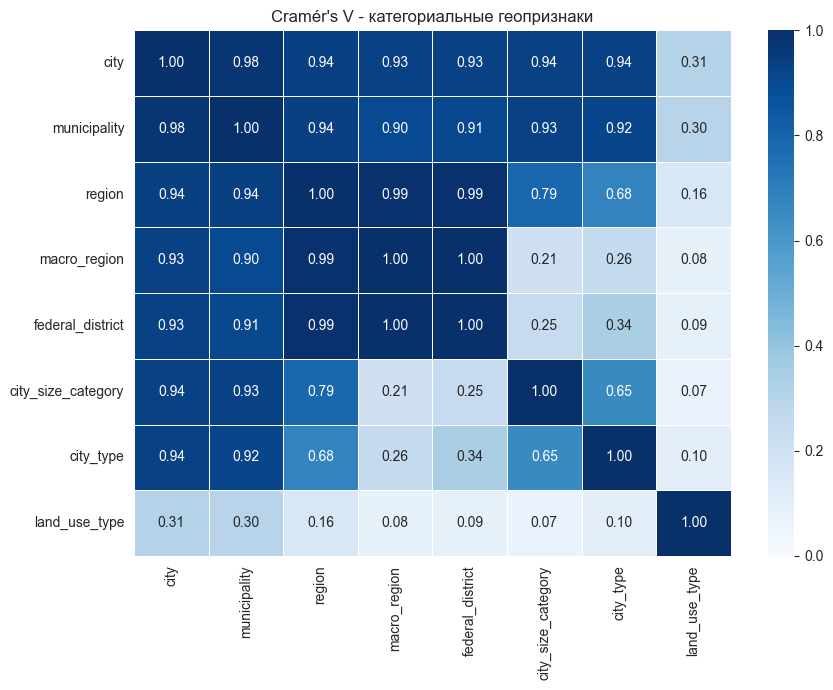

In [32]:
cat_check_cols = [c for c in [
    "city", "municipality", "region", "city_grouped", "macro_region", 
    "federal_district", "city_size_category", "city_type", "land_use_type"
] if c in df.columns]

def cramers_v(x, y):
    ct   = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2c = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rc = r - (r-1)**2/(n-1)
    kc = k - (k-1)**2/(n-1)
    denom = min(kc-1, rc-1)
    return float(np.sqrt(phi2c / denom)) if denom > 0 else 0.0

cv_matrix = pd.DataFrame(index=cat_check_cols, columns=cat_check_cols, dtype=float)
for c1 in cat_check_cols:
    for c2 in cat_check_cols:
        cv_matrix.loc[c1, c2] = cramers_v(
            df[c1].fillna("NA").astype(str), df[c2].fillna("NA").astype(str))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cv_matrix.astype(float), annot=True, fmt=".2f",
            cmap="Blues", ax=ax, vmin=0, vmax=1, linewidths=0.5)
ax.set_title("Cramér's V - категориальные геопризнаки")
plt.tight_layout()
plt.show()

- `city`, `municipality`, `region` и `city_grouped` сильно связаны между собой: особенно `city` ↔ `municipality` (`V = 0.98`), а также `city`/`municipality` ↔ `region` (`V ≈ 0.94`). Это ожидаемо, так как город и муниципалитет вложены в регион.
- `macro_region` и `federal_district` практически дублируют друг друга (`V = 1.00`) и также почти полностью определяются через `region` (`V = 0.99`), поэтому несут очень похожую агрегированную региональную информацию.
- `city_size_category` и `city_type` умеренно зависимы (`V = 0.65`), но не являются полными дублями: размер города и его тип отражают разные аспекты населенного пункта.
- `land_use_type` слабо связан с остальными категориальными признаками (`V ≈ 0.07–0.31`), поэтому он добавляет более самостоятельную информацию.

## 12. Сравнение важностей признаков

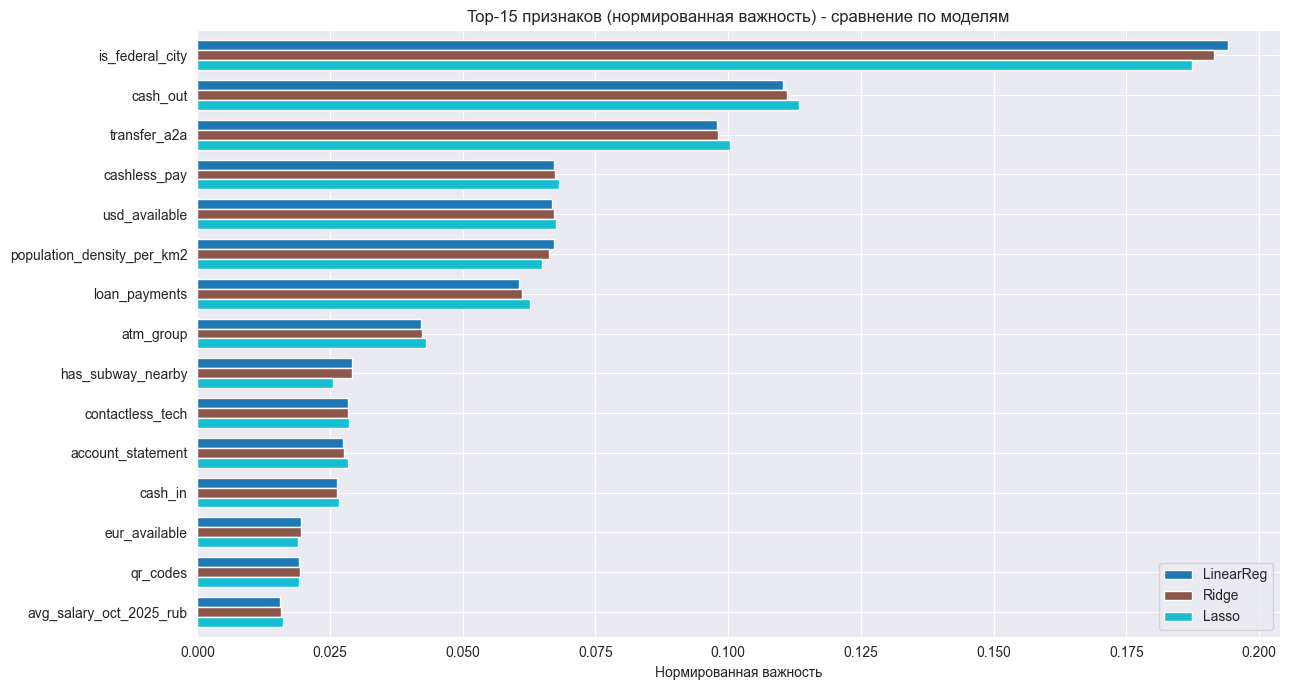

In [33]:
def get_norm_importance(pipe):
    names = pipe.named_steps['prep'].get_feature_names_out()
    vals  = np.abs(pipe.named_steps['model'].coef_)
    clean = [n.split('__', 1)[-1] for n in names]
    s = pd.Series(vals, index=clean)
    return s / s.sum()


imp_lr_n    = get_norm_importance(lr_pipe)
imp_ridge_n = get_norm_importance(ridge_pipe)
imp_lasso_n = get_norm_importance(lasso_pipe)

# Top-15 по Ridge (наиболее стабильный)
top15 = imp_ridge_n.sort_values(ascending=False).head(15).index

imp_compare = pd.DataFrame({
    'LinearReg': imp_lr_n.reindex(top15),
    'Ridge':     imp_ridge_n.reindex(top15),
    'Lasso':     imp_lasso_n.reindex(top15),
}).fillna(0)

fig, ax = plt.subplots(figsize=(13, 7))
imp_compare.plot(kind='barh', ax=ax, colormap='tab10', width=0.75)
ax.set_title('Top-15 признаков (нормированная важность) - сравнение по моделям')
ax.set_xlabel('Нормированная важность')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

- Топ-признаки устойчивы во всех трёх моделях: `is_federal_city`, `cash_out`, `transfer_a2a`
- **Бинарные ATM-фичи** доминируют - функциональность банкомата важнее отдельных дистанционных и счётных признаков
- `is_federal_city` и `has_subway_nearby` - наиболее информативные геопризнаки среди топа
- Регуляризация (Ridge/Lasso) почти не меняет порядок топ-признаков → структура линейного сигнала стабильна
- Важность категориальных признаков с `OrdinalEncoder` нужно трактовать осторожно: коэффициенты зависят от искусственного порядка категорий